In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader , random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report , roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import torch
import torch.nn.functional as F
import kagglehub
import shutil
import math

import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
import collections


# 1) DATASET DOWNLOAD & SETUP

In [ ]:

target_dir = "dataset"

if not os.path.exists(target_dir):
    print("Dataset folder not found. Downloading...")

    cache_path = kagglehub.dataset_download("divyam6969/chest-xray-pneumonia-dataset")
    print("Downloaded to:", cache_path)

    shutil.copytree(cache_path, target_dir)
    print("Dataset saved to:", target_dir)
else:
    print("Dataset already exists. Skipping download.")

test_dir = os.path.join(target_dir, "test")

class_mapping = {
    "normal": "NORMAL",
    "bacteria": "BACTERIAL",
    "virus": "VIRAL"
}

for folder_name in class_mapping.values():
    folder_path = os.path.join(test_dir, folder_name)
    os.makedirs(folder_path, exist_ok=True)


for filename in os.listdir(test_dir):
    file_path = os.path.join(test_dir, filename)
    if os.path.isfile(file_path):
        # Check which keyword is in the filename
        lower_filename = filename.lower()
        for keyword, folder_name in class_mapping.items():
            if keyword in lower_filename:
                dest_path = os.path.join(test_dir, folder_name, filename)
                shutil.move(file_path, dest_path)
                break  # stop checking once matched

print("Test folder organized into class subfolders: NORMAL, BACTERIA, VIRAL.")


/Users/ivya/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/ivya/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset folder not found. Downloading...


100%|██████████| 1.07G/1.07G [00:57<00:00, 20.0MB/s]

Extracting files...


Downloaded to: /Users/ivya/.cache/kagglehub/datasets/divyam6969/chest-xray-pneumonia-dataset/versions/1
Dataset saved to: dataset
Test folder organized into class subfolders: NORMAL, BACTERIA, VIRAL.


# 2) TRANSFORMS & DATASET

 Helper function for plotting distributions

In [ ]:
def plot_distribution(class_counts, class_names, title):
    """
    Plots a bar chart of the class distribution.

    Args:
        class_counts (collections.Counter): A Counter object mapping class index to count.
        class_names (list): A list of the actual class names.
        title (str): The title for the plot.
    """

    counts = [class_counts[i] for i in sorted(class_counts.keys())]
    names = [class_names[i] for i in sorted(class_counts.keys())]
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6))

    bars = ax.bar(names, counts, color=plt.cm.Paired(np.arange(len(names))))
    ax.set_title(title, fontsize=16)
    ax.set_ylabel('Number of Samples', fontsize=12)
    ax.set_xlabel('Class', fontsize=12)
    plt.xticks(rotation=45, ha="right")

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + 5, int(yval),
                ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

Define Transformers

In [ ]:
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# --- Define Transforms ---
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Dataset Loading and Splitting

In [ ]:
train_dir = "dataset/train"
full_train_dataset = datasets.ImageFolder(train_dir, transform=None)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
torch.manual_seed(42)
train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size])

train_dataset = TransformedSubset(train_subset, transform=train_transforms)
val_dataset = TransformedSubset(val_subset, transform=val_transforms)

print("\n--- Dataset Summary ---")
print("Total images:", len(full_train_dataset))
print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))


--- Dataset Summary ---
Total images: 5216
Train images: 4172
Validation images: 1044


Training Set Class Exploration


--- Class Distribution in Training Set (Before Balancing) ---
Class 'BACTERIAL': 2026 samples
Class 'NORMAL': 1060 samples
Class 'VIRAL': 1086 samples


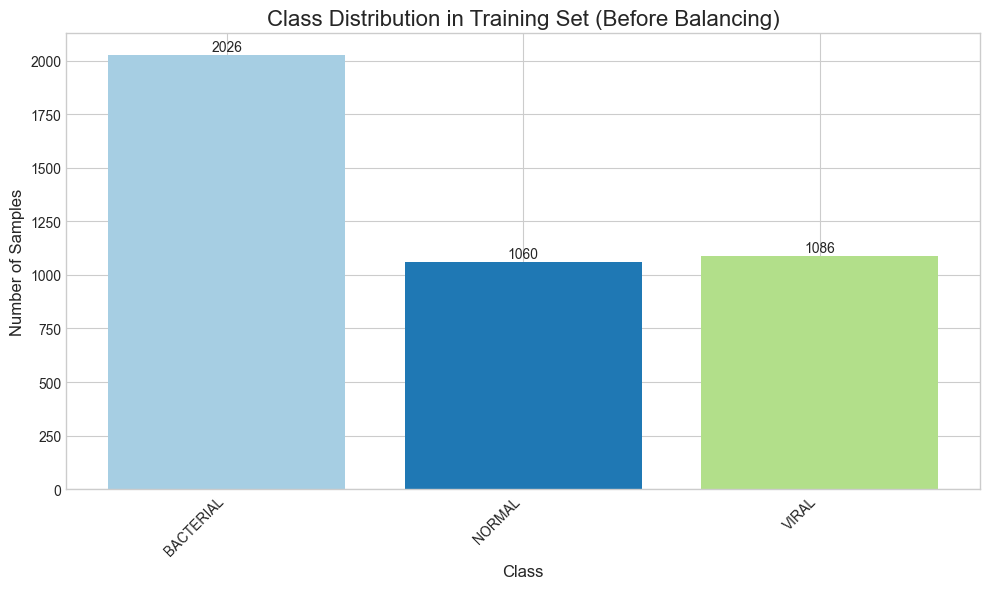

In [ ]:
print("\n--- Class Distribution in Training Set (Before Balancing) ---")
train_targets = [label for _, label in train_subset]
class_counts_before = collections.Counter(train_targets)
class_names = full_train_dataset.classes

for i in sorted(class_counts_before.keys()):
    print(f"Class '{class_names[i]}': {class_counts_before[i]} samples")

# --- VISUALIZATION (BEFORE) ---
plot_distribution(
    class_counts=class_counts_before,
    class_names=class_names,
    title="Class Distribution in Training Set (Before Balancing)"
)

Addressing data imbalance with WeightedRandomSampler

In [ ]:
class_counts = np.bincount(train_targets)
class_weights = 1. / class_counts
sample_weights = np.array([class_weights[t] for t in train_targets])
sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).double(),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("\nDataLoaders created.")





DataLoaders created.


Class Distribution in one epoch from DataLoader (After Balancing)

Class 'BACTERIAL': 1397 samples drawn
Class 'NORMAL': 1390 samples drawn
Class 'VIRAL': 1385 samples drawn


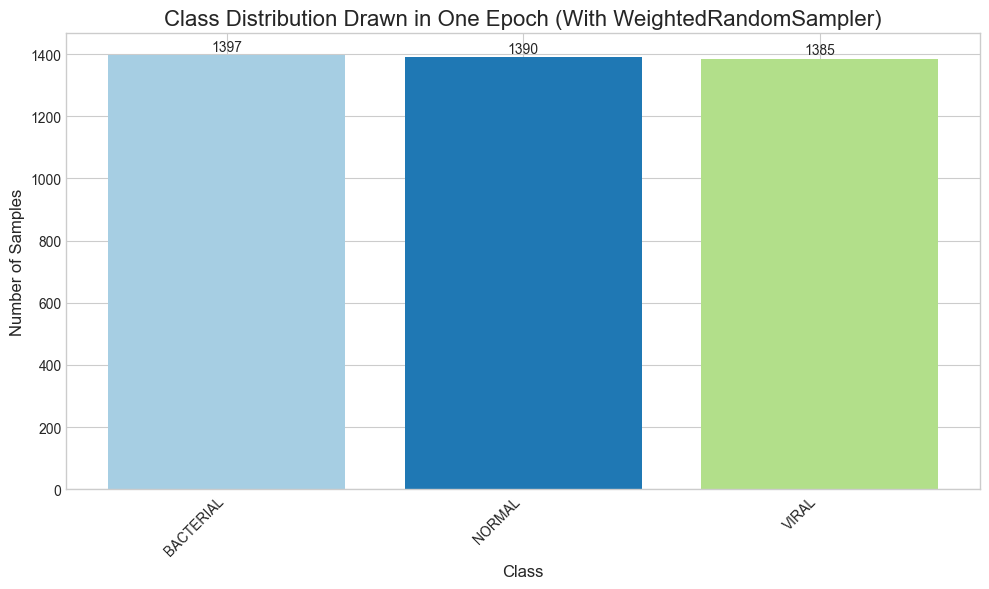

In [ ]:
train_targets_after = []
for _, labels in train_loader:
    train_targets_after.extend(labels.numpy())

class_counts_after = collections.Counter(train_targets_after)

for i in sorted(class_counts_after.keys()):
    print(f"Class '{class_names[i]}': {class_counts_after[i]} samples drawn")

# --- VISUALIZATION (AFTER) ---
plot_distribution(
    class_counts=class_counts_after,
    class_names=class_names,
    title="Class Distribution Drawn in One Epoch (With WeightedRandomSampler)"
)

# 3) MODEL DEFINITION

In [ ]:

class ChestXrayCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(ChestXrayCNN, self).__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(2,2)
            )

        self.block1 = conv_block(3, 32)
        self.block2 = conv_block(32, 64)
        self.block3 = conv_block(64, 128)
        self.block4 = conv_block(128, 256)

        self.gap = nn.AdaptiveAvgPool2d((1,1))

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        x = self.fc(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = ChestXrayCNN(num_classes=3).to(device)

Using device: cpu


# 4) PYTORCH LR FINDER



Running LR Finder...
Batch 0/131 LR=0.000000 Loss=1.0951
Batch 20/131 LR=0.000002 Loss=1.1896
Batch 40/131 LR=0.000032 Loss=1.0594
Batch 60/131 LR=0.000531 Loss=0.8550
Batch 80/131 LR=0.008842 Loss=0.6655
Batch 100/131 LR=0.147211 Loss=1.0252
Batch 120/131 LR=2.450829 Loss=1.4785


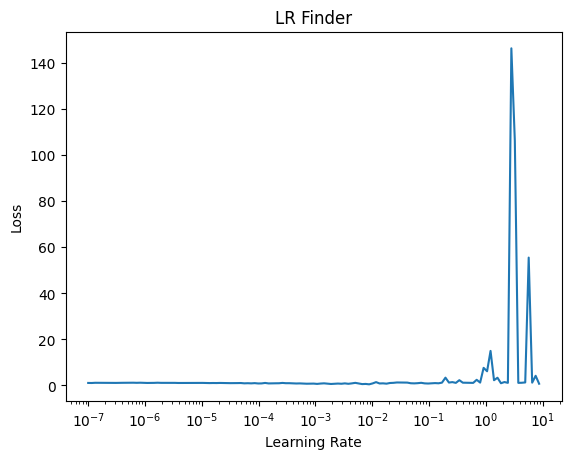

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def lr_find(model, loader, optimizer, criterion, start_lr=1e-7, end_lr=10):
    model.train()
    num_batches = len(loader)
    lr_mult = (end_lr/start_lr)**(1/num_batches)
    lr = start_lr
    optimizer.param_groups[0]["lr"] = lr

    losses = []
    lrs = []

    for batch_i, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        lrs.append(lr)

        lr *= lr_mult
        optimizer.param_groups[0]["lr"] = lr

        if batch_i % 20 == 0:
            print(f"Batch {batch_i}/{num_batches} LR={lr:.6f} Loss={loss.item():.4f}")

    plt.plot(lrs, losses)
    plt.xscale("log")
    plt.xlabel("Learning Rate")
    plt.ylabel("Loss")
    plt.title("LR Finder")
    plt.show()


print("\nRunning LR Finder...")
lr_find(model, train_loader, optimizer, criterion)

# 5) LOSS, OPTIMIZER, ONE CYCLE LR

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=num_epochs
)

# 6) Model Training

In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_accuracy = 0

for epoch in range(num_epochs):

    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    train_acc = 100 * train_correct / train_total

    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)


    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {avg_val_loss:.4f} | Val   Acc: {val_acc:.2f}%")
    print("-"*50)

    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), "best_chest_xray_model.pth")
        print(f"Best Model Saved! New Best Val Acc = {val_acc:.2f}%")

print("\nTraining Complete!")
print(f"Best Validation Accuracy: {best_val_accuracy:.2f}%")


Epoch [1/20]
Train Loss: 0.8776 | Train Acc: 60.47%
Val   Loss: 0.7048 | Val   Acc: 72.61%
--------------------------------------------------
Best Model Saved! New Best Val Acc = 72.61%

Epoch [2/20]
Train Loss: 0.7315 | Train Acc: 67.83%
Val   Loss: 0.8077 | Val   Acc: 53.16%
--------------------------------------------------

Epoch [3/20]
Train Loss: 0.6453 | Train Acc: 71.52%
Val   Loss: 0.6586 | Val   Acc: 73.95%
--------------------------------------------------
Best Model Saved! New Best Val Acc = 73.95%

Epoch [4/20]
Train Loss: 0.6006 | Train Acc: 72.27%
Val   Loss: 0.9539 | Val   Acc: 54.02%
--------------------------------------------------

Epoch [5/20]
Train Loss: 0.5566 | Train Acc: 74.59%
Val   Loss: 1.0521 | Val   Acc: 46.46%
--------------------------------------------------

Epoch [6/20]
Train Loss: 0.5599 | Train Acc: 74.47%
Val   Loss: 0.7206 | Val   Acc: 68.39%
--------------------------------------------------

Epoch [7/20]
Train Loss: 0.5401 | Train Acc: 75.34%
V

# 7) CONFUSION MATRIX + ERROR ANALYSIS

In [ ]:
class Interpretation:
    def __init__(self, model, loader,class_names, criterion):
        self.model = model
        self.loader = loader
        self.criterion = criterion
        self.class_names = class_names
        self.preds = []
        self.targets = []
        self.losses = []
        self.probs = []


    def evaluate(self):
        self.model.eval()
        self.preds.clear()
        self.targets.clear()
        self.losses.clear()

        with torch.no_grad():
            for images, labels in self.loader:
                images, labels = images.to(device), labels.to(device)
                outputs = self.model(images)

                probabilities = F.softmax(outputs, dim=1)
                self.probs.extend(probabilities.cpu().numpy())
                loss = F.cross_entropy(outputs, labels, reduction='none')
                _, predicted = torch.max(outputs, 1)

                self.preds.extend(predicted.cpu().numpy())
                self.targets.extend(labels.cpu().numpy())
                self.losses.extend(loss.cpu().numpy())

    def plot_confusion_matrix(self):
        cm = confusion_matrix(self.targets, self.preds)
        disp = ConfusionMatrixDisplay(cm, display_labels=self.class_names)
        disp.plot(cmap='Blues', xticks_rotation=45)
        plt.title("Confusion Matrix")
        plt.show()

    def plot_top_losses(self, k=9):
        losses = np.array(self.losses)
        preds = np.array(self.preds)
        targets = np.array(self.targets)

        top_loss_indices = np.argsort(losses)[-k:]

        fig, axes = plt.subplots(int(math.ceil(k/3)), 3, figsize=(15, 10))
        axes = axes.flatten()

        for i, idx in enumerate(top_loss_indices):
            image, _ = self.loader.dataset[idx]

            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            image = image.permute(1, 2, 0).numpy() * std + mean
            image = np.clip(image, 0, 1)

            ax = axes[i]
            ax.imshow(image)
            pred_class = self.class_names[preds[idx]]
            actual_class = self.class_names[targets[idx]]
            ax.set_title(f"Pred: {pred_class}\nActual: {actual_class}\nLoss: {losses[idx]:.2f}")
            ax.axis('off')

        plt.suptitle("Top Losses", fontsize=16)
        plt.tight_layout()
        plt.show()

    def plot_roc_curve(self):
        y_true = np.array(self.targets)
        y_prob = np.array(self.probs)
        n_classes = len(self.class_names)


        y_true_binarized = label_binarize(y_true, classes=range(n_classes))

        fpr = dict()
        tpr = dict()
        roc_auc = dict()

        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_prob[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        plt.figure(figsize=(8, 6))
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

        for i, color in zip(range(n_classes), colors):
            plt.plot(fpr[i], tpr[i], color=color, lw=2,
                    label=f'{self.class_names[i]} (AUC = {roc_auc[i]:.2f})')

        plt.plot([0, 1], [0, 1], 'k--', lw=2)

        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve (Multiclass - One-vs-Rest)')
        plt.legend(loc="lower right")
        plt.grid(False)
        plt.show()


## 7.1)  Test Dataset

In [ ]:
test_dir = "dataset/test"

test_dataset = datasets.ImageFolder(test_dir, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

interp = Interpretation(model, test_loader, test_loader.dataset.classes, criterion)

print("Running evaluation on the test set...")
interp.evaluate()

Running evaluation on the test set...


### 7.1.1) Confusion Matrix

Confusion Matrix of Test Data


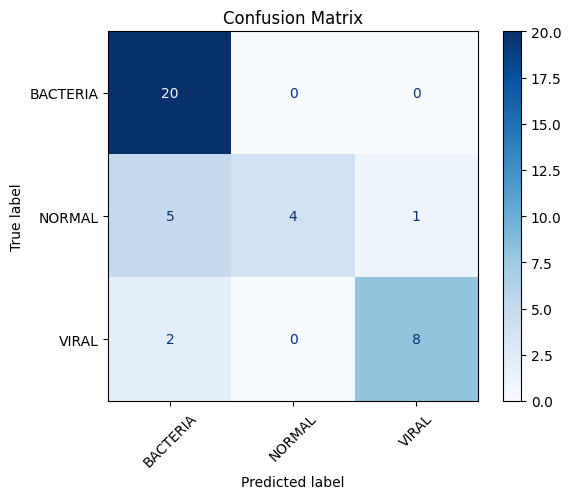


 Classification Report:

              precision    recall  f1-score   support

    BACTERIA       0.74      1.00      0.85        20
      NORMAL       1.00      0.40      0.57        10
       VIRAL       0.89      0.80      0.84        10

    accuracy                           0.80        40
   macro avg       0.88      0.73      0.75        40
weighted avg       0.84      0.80      0.78        40



In [ ]:
print("Confusion Matrix of Test Data")
interp.plot_confusion_matrix()
print("\n Classification Report:\n")
print(classification_report(interp.targets, interp.preds, target_names=interp.class_names))

### 7.1.2) Qualitative Analysis of Misclassified Images of Test Data

Qualitative Analysis of Misclassified Images of Test Data


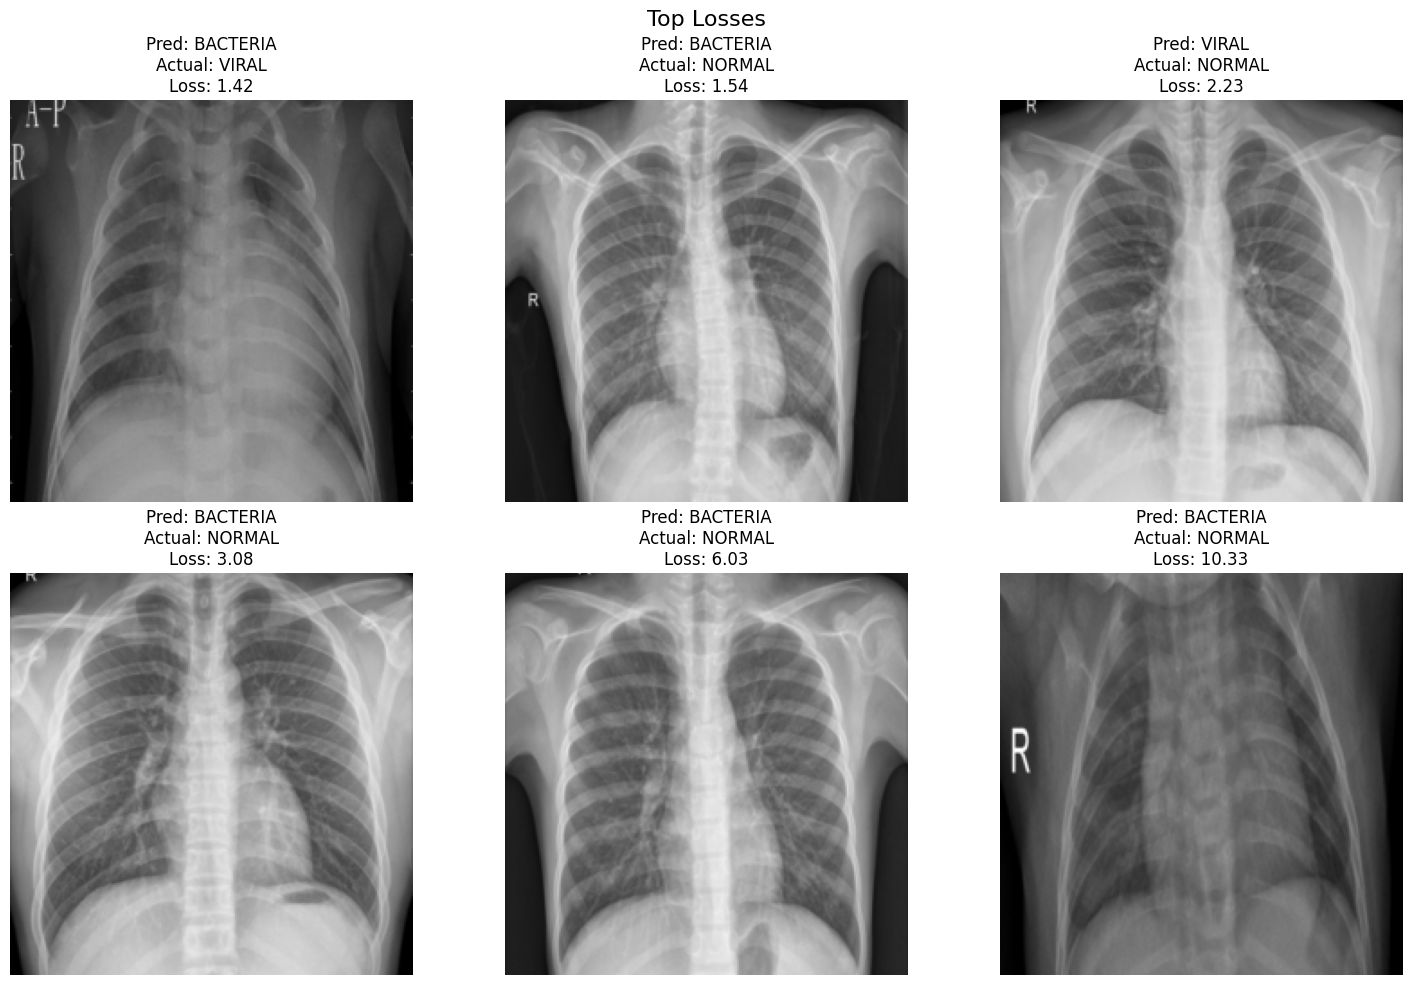

In [ ]:
print("Qualitative Analysis of Misclassified Images of Test Data")
interp.plot_top_losses(k=6)

### 7.1.3) ROC Curve for Test Data

ROC Curve for Test Data


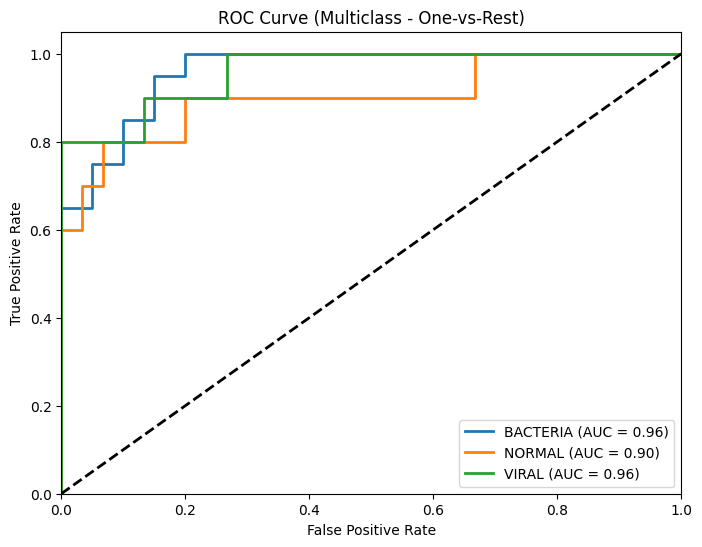

In [ ]:
print("ROC Curve for Test Data")
interp.plot_roc_curve()


## 7.2) VALIDATION DATASET

In [ ]:
interp = Interpretation(model, val_loader,full_train_dataset.classes, criterion)

print("Running evaluation on the Vaidation set...")
interp.evaluate()

Running evaluation on the Vaidation set...


### 7.2.1) Confusion Matrix

Confusion Matrix of Validation Data


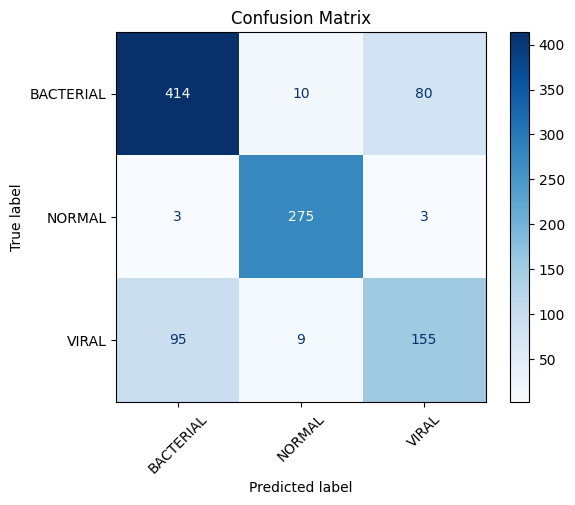


 Validation Set Classification Report:

              precision    recall  f1-score   support

   BACTERIAL       0.81      0.82      0.81       504
      NORMAL       0.94      0.98      0.96       281
       VIRAL       0.65      0.60      0.62       259

    accuracy                           0.81      1044
   macro avg       0.80      0.80      0.80      1044
weighted avg       0.80      0.81      0.81      1044



In [ ]:
print("Confusion Matrix of Validation Data")
interp.plot_confusion_matrix()
print("\n Validation Set Classification Report:\n")
print(classification_report(interp.targets, interp.preds, target_names=full_train_dataset.classes))

### 7.2.2) Qualitative Analysis of Misclassified Images of Test Data

Qualitative Analysis of Misclassified Images of Validation Data


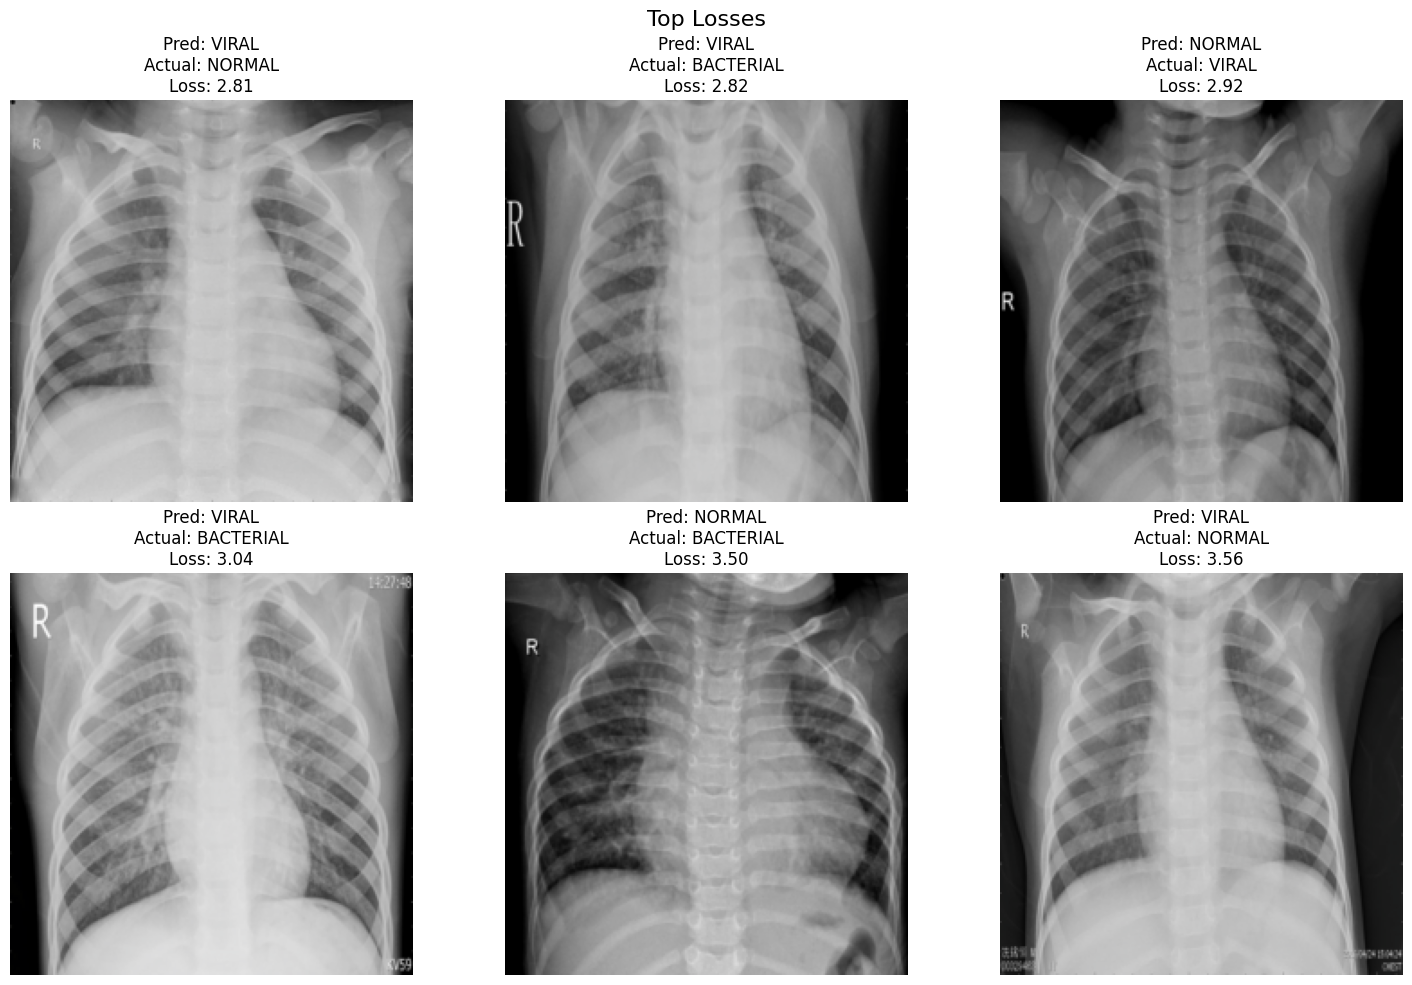

In [ ]:
print("Qualitative Analysis of Misclassified Images of Validation Data")
interp.plot_top_losses(k=6)

### 7.2.3) ROC Curve for Validation Data

ROC Curve for Validation Data


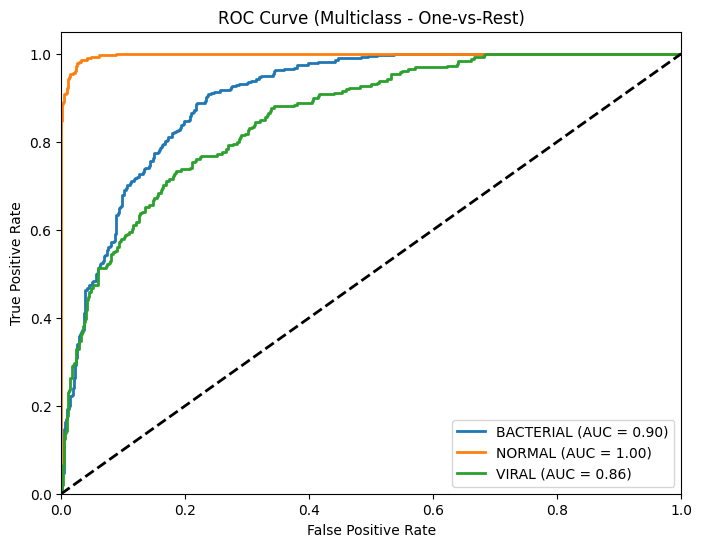

In [ ]:
print("ROC Curve for Validation Data")
interp.plot_roc_curve()


# 8) LEARNING CURVES

## 8.1) Loss Curve

Text(0.5, 1.0, 'Loss Curve')

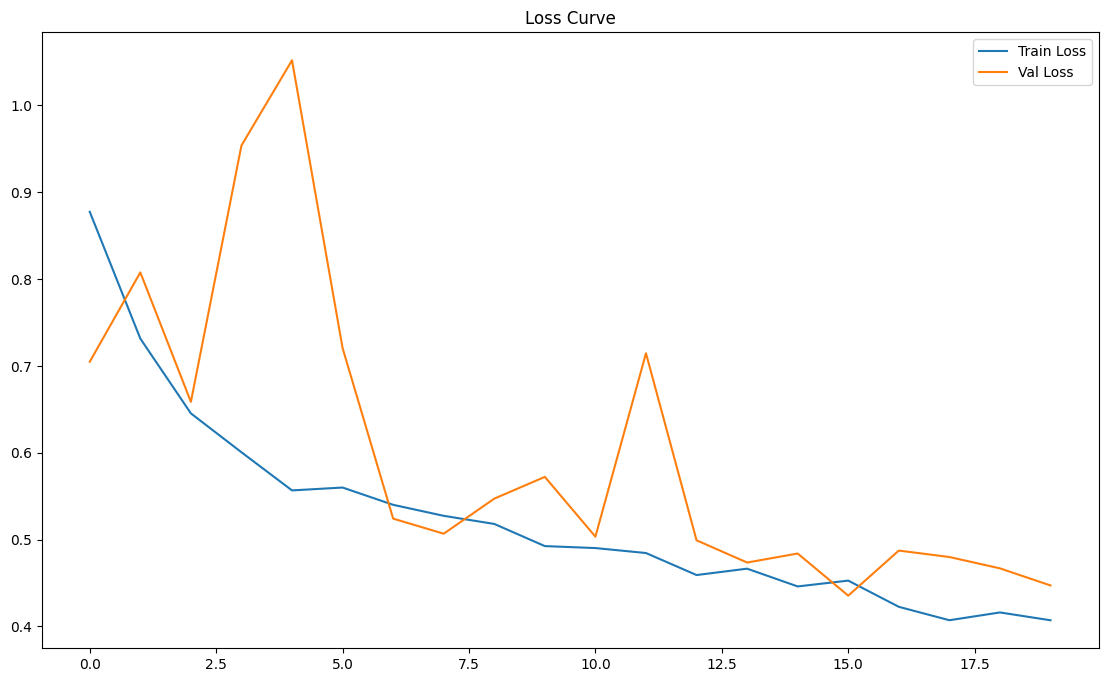

In [ ]:
plt.figure(figsize=(30,8))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")

## 8.2) Accuracy Curve

Text(0.5, 1.0, 'Accuracy Curve')

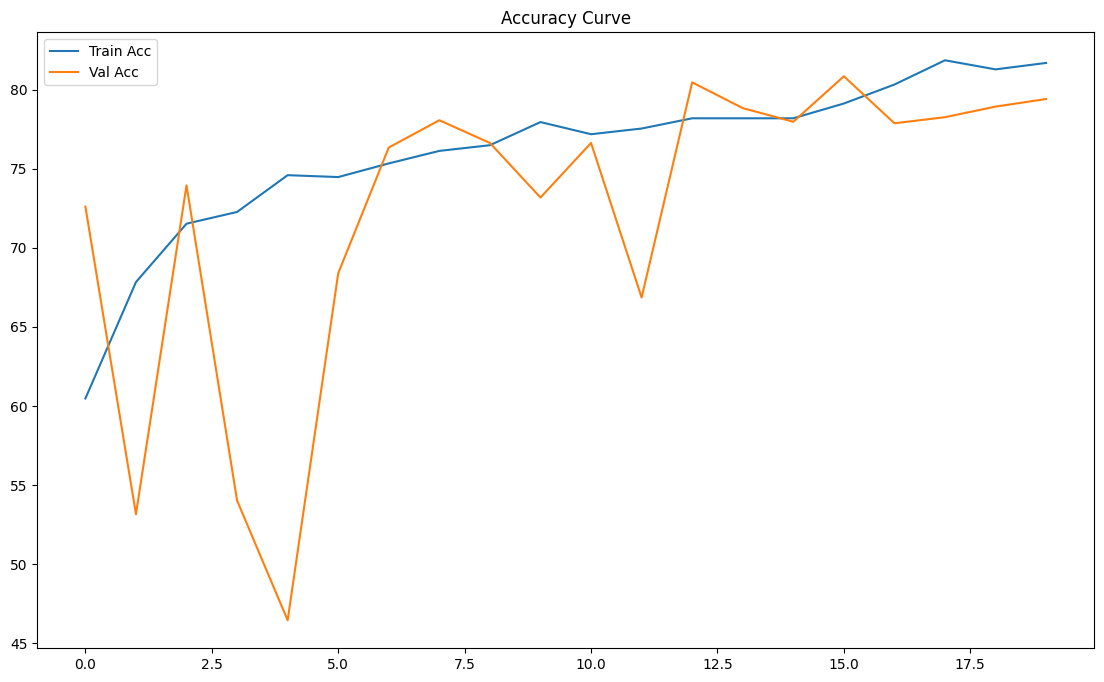

In [ ]:
plt.figure(figsize=(30,8))
plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(val_accuracies, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")

# 9) Import the Model and test with an image

Weights loaded from best_chest_xray_model.pth

--- Result for: testing_image.jpeg ---
Prediction: VIRAL
Confidence: 93.05%

Detailed Probabilities:
  BACTERIAL: 6.94%
  NORMAL: 0.01%
  VIRAL: 93.05%


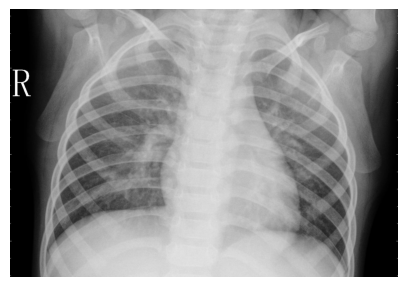

In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import os

CLASS_NAMES = ['BACTERIAL', 'NORMAL', 'VIRAL']


# MODEL ARCHITECTURE
class ChestXrayCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(ChestXrayCNN, self).__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(2,2)
            )

        self.block1 = conv_block(3, 32)
        self.block2 = conv_block(32, 64)
        self.block3 = conv_block(64, 128)
        self.block4 = conv_block(128, 256)

        self.gap = nn.AdaptiveAvgPool2d((1,1))

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        x = self.fc(x)
        return x



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ChestXrayCNN(num_classes=3)

model_path = "best_chest_xray_model.pth"

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Weights loaded from {model_path}")
else:
    print(f"Error: Could not find {model_path}")
    exit()

model.to(device)
model.eval()



# PREPROCESSING
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])



# PREDICTION FUNCTION
def predict_image(image_path):
    try:
        image = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f"Could not open image {image_path}: {e}")
        return

     # Show the image
    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.axis('off')


    # Transform Image
    input_tensor = inference_transform(image)

    # 3. Add Batch Dimension
    input_batch = input_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_batch)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        _, predicted_idx = torch.max(output, 1)

        confidence = probabilities[predicted_idx].item()
        label = CLASS_NAMES[predicted_idx.item()]


    print(f"\n--- Result for: {os.path.basename(image_path)} ---")
    print(f"Prediction: {label.upper()}")
    print(f"Confidence: {confidence * 100:.2f}%")

    print("\nDetailed Probabilities:")
    for i, class_name in enumerate(CLASS_NAMES):
        print(f"  {class_name}: {probabilities[i].item() * 100:.2f}%")



# 6. Execution
# Image Path , Example: "C:/Users/Downloads/test_xray.jpeg"
test_image_path = "testing_image.jpeg"

predict_image(test_image_path)